In [1]:
import pandas as pd

# Original MoMA dataset
original = pd.read_csv("../data/artists.csv")

# Dataset prepared for enrichment
before = pd.read_csv("../data/artists_prepared_for_wikidata.csv")

# Final enriched dataset
after = pd.read_csv("../data/data_artists_enriched.csv")

In [2]:
total_original = len(original)
total_to_enrich = len(before)

matched = (after["match_status"] == "matched").sum()
uncertain = (after["match_status"] == "uncertain").sum()
not_found = (after["match_status"] == "not_found").sum()

match_rate = matched / total_to_enrich * 100

print(f"Original artists: {total_original}")
print(f"Artists requiring enrichment: {total_to_enrich}")
print(f"Matched: {matched}")
print(f"Uncertain: {uncertain}")
print(f"Not Found: {not_found}")
print(f"Overall Match Rate: {match_rate:.2f}%")

Original artists: 15091
Artists requiring enrichment: 10525
Matched: 5186
Uncertain: 1944
Not Found: 3375
Overall Match Rate: 49.27%


In [3]:
birth_missing_before = before["Birth Year"].isna().sum()
birth_missing_after = after["Birth Year"].isna().sum()

death_missing_before = before["Death Year"].isna().sum()
death_missing_after = after["Death Year"].isna().sum()

birth_added = birth_missing_before - birth_missing_after
death_added = death_missing_before - death_missing_after

print("Birth missing BEFORE:", birth_missing_before)
print("Birth missing AFTER :", birth_missing_after)

print()

print("Death missing BEFORE:", death_missing_before)
print("Death missing AFTER :", death_missing_after)

print()

print("Birth Years Added:", birth_added)
print("Death Years Added:", death_added)

Birth missing BEFORE: 3854
Birth missing AFTER : 3354

Death missing BEFORE: 10512
Death missing AFTER : 9278

Birth Years Added: 500
Death Years Added: 1234


In [4]:
summary = pd.DataFrame({

    "Metric":[

        "Original artists",

        "Artists requiring enrichment",

        "Successfully matched",

        "Uncertain matches",

        "Not found",

        "Birth Years added",

        "Death Years added",

        "Overall Match Rate"

    ],

    "Value":[

        total_original,

        total_to_enrich,

        matched,

        uncertain,

        not_found,

        birth_added,

        death_added,

        f"{match_rate:.2f}%"

    ]

})

summary

,Metric,Value
0,Original artists,15091
1,Artists requiring enrichment,10525
2,Successfully matched,5186
3,Uncertain matches,1944
4,Not found,3375
5,Birth Years added,500
6,Death Years added,1234
7,Overall Match Rate,49.27%


In [5]:
summary.to_csv("../data/project_summary.csv",index=False)

print("Summary exported successfully!")

Summary exported successfully!


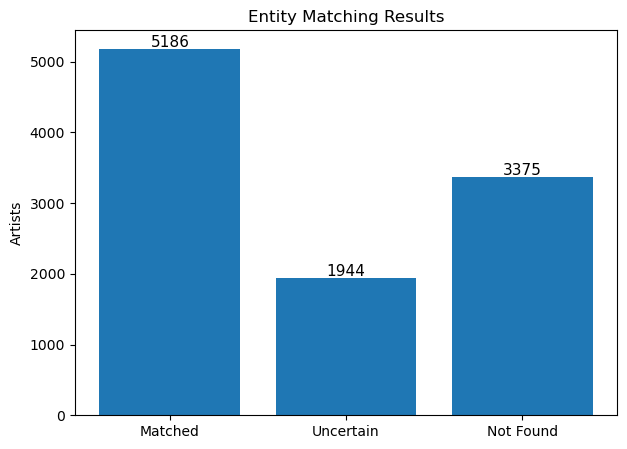

In [6]:
import matplotlib.pyplot as plt

labels = ["Matched","Uncertain","Not Found"]

counts = [matched,uncertain,not_found]

plt.figure(figsize=(7,5))

bars = plt.bar(labels,counts)

plt.title("Entity Matching Results")

plt.ylabel("Artists")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+30,
        f"{int(height)}",
        ha="center",
        fontsize=11
    )

plt.show()

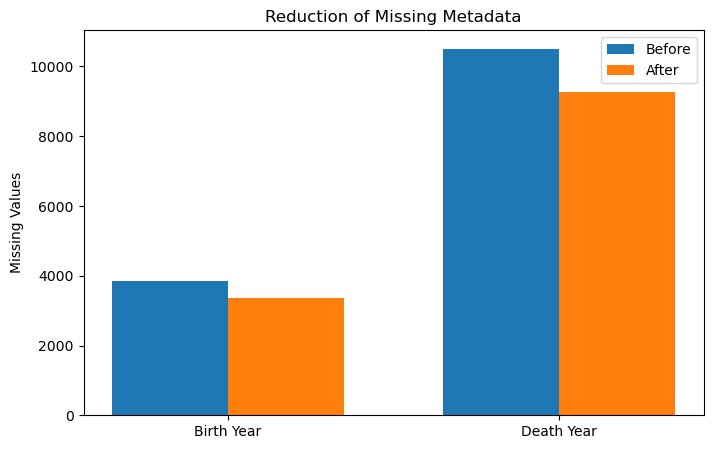

In [7]:
labels = ["Birth Year","Death Year"]

before_missing = [

    birth_missing_before,

    death_missing_before

]

after_missing = [

    birth_missing_after,

    death_missing_after

]

x = range(len(labels))

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(

    [i-width/2 for i in x],

    before_missing,

    width,

    label="Before"

)

plt.bar(

    [i+width/2 for i in x],

    after_missing,

    width,

    label="After"

)

plt.xticks(x,labels)

plt.ylabel("Missing Values")

plt.title("Reduction of Missing Metadata")

plt.legend()

plt.show()

In [8]:
print("="*50)

print("PROJECT IMPACT")

print("="*50)

print()

print(f"Original dataset: {total_original:,} artists")

print(f"Artists requiring enrichment: {total_to_enrich:,}")

print()

print(f"Matched: {matched:,}")

print(f"Uncertain: {uncertain:,}")

print(f"Not found: {not_found:,}")

print()

print(f"Birth Years added: {birth_added:,}")

print(f"Death Years added: {death_added:,}")

print()

print(f"Overall Match Rate: {match_rate:.2f}%")

PROJECT IMPACT

Original dataset: 15,091 artists
Artists requiring enrichment: 10,525

Matched: 5,186
Uncertain: 1,944
Not found: 3,375

Birth Years added: 500
Death Years added: 1,234

Overall Match Rate: 49.27%
